# Phase 2 — Data Ablation (TA-compliant, built on v2.3 pipeline)

**Question:** beyond the TA-mandated FRED-MD + lagged close baseline, which additional data groups actually lift accuracy?

**Three groups (all already collected in `alternative_data/raw/`):**
- **A — TECH**: technical indicators from wheat OHLCV (RSI, MACD, Bollinger %B, ATR, momentum 5/10/20, volume z-score, intraday range, open-close return).
- **B — COT**: CFTC Commitment-of-Traders positioning — hedging pressure, speculator-net, 4-week position momentum, 52-week extreme z-score.
- **C — CROSS**: cross-commodity context — wheat/corn ratio, wheat/soy ratio, crude return, DXY change, gold return, rolling wheat-corn correlation.

**Ablation matrix — 8 configs, full power set on top of baseline:**

| # | Config | Features |
|---|---|---|
| 0 | Baseline | FRED-MD + close + log-return |
| 1 | +A | baseline + TECH |
| 2 | +B | baseline + COT |
| 3 | +C | baseline + CROSS |
| 4 | +AB | baseline + TECH + COT |
| 5 | +AC | baseline + TECH + CROSS |
| 6 | +BC | baseline + COT + CROSS |
| 7 | +ABC | baseline + all three |

**Protocol (identical to v2.3):**
- FRED-MD preprocessing unchanged — 31 TA variables + t-codes + 1-month publication lag + daily forward-fill.
- Dataset clipped to `2008-01-01+`.
- 30-day rolling window, next-day direction target.
- 5-fold `TimeSeriesSplit` over full 2008+ data, per-fold scaler fit on train only.
- Per-fold threshold tuning on train predictions.
- **Per-cell Optuna with 30 trials** (TPE + MedianPruner, maximises mean val AUC).
- **Single-seed (seed=42) for all cells** to keep cross-config comparisons fair. No seed ensembling — that's a headline-polish step for the winning config after ablation.
- Models: ARX, BiGRU, BiRNN+Attention, BiRNN+Skip. BiGRU and Skip tune `pool` (last/mean/max).

**Budget:** 8 configs × 3 deep models = 24 Optuna cells + ARX runs on 8 configs. Expected wall time ≈ 4–5 h on A100.

**Output:**
- Main matrix (8 rows × 4 model cols × {acc, auc}).
- Per-group marginal lift table (avg of configs including that group vs avg of configs excluding it).
- Winning config highlighted.
- Artifacts: `phase2_ablation_summary.csv`, per-cell `best_params.json`, Optuna trial histories.

In [1]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.1 MB/s eta 0:00:00


In [2]:
from abc import ABC, abstractmethod
from pathlib import Path
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, f1_score,
                             balanced_accuracy_score)
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import warnings; warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print('Device:', DEVICE)

Device: cuda


In [3]:
class BaseForecastModel(ABC):
    def __init__(self, task_type, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters
    @abstractmethod
    def fit(self, X_train, y_train): pass
    @abstractmethod
    def predict(self, X): pass
    @abstractmethod
    def evaluate(self, X_test, y_test): pass
    @abstractmethod
    def save(self, fp): pass
    @abstractmethod
    def load(self, fp): pass

In [4]:
from google.colab import drive
drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/Quants ')
WHEAT_18 = BASE / 'Investing.com' / 'US Wheat Futures Historical Data_2018.csv'
WHEAT_25 = BASE / 'Investing.com' / 'US Wheat Futures Historical Data_2025.csv'
FRED = BASE / 'FredMD_Dataset' / '2025-10-MD.csv'
# Alternative-data raw CSVs. Expected under Drive; upload/copy there first if absent.
ALT = BASE / 'alternative_data' / 'raw'
OUT_DIR = BASE / 'phase2_ablation_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)
print('ALT dir exists:', ALT.exists(), ' — files:', [p.name for p in ALT.glob('*.csv')] if ALT.exists() else 'N/A')

Mounted at /content/drive
ALT dir exists: True  — files: ['soybean_futures.csv', 'corn_futures.csv', 'crude_oil_wti.csv', 'usd_index.csv', 'gold_futures.csv', 'cot_wheat_disaggregated.csv', 'google_trends.csv', 'weather_kansas.csv', 'weather_north_dakota.csv', 'nasa_power_ag.csv', 'vix.csv', 'ovx.csv']


## 1. Load wheat OHLCV (full: Close, Open, High, Low, Volume)

In [5]:
def parse_volume(v):
    if pd.isna(v): return np.nan
    v = str(v).replace(',', '').strip()
    if v in ('', '-'): return np.nan
    mult = 1.0
    if v.endswith('K'): mult, v = 1e3, v[:-1]
    elif v.endswith('M'): mult, v = 1e6, v[:-1]
    try: return float(v) * mult
    except: return np.nan

def load_ohlcv(p):
    df = pd.read_csv(p)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    for c in ['Price','Open','High','Low']:
        df[c] = df[c].astype(str).str.replace(',', '', regex=False).astype(float)
    df['Volume'] = df['Vol.'].apply(parse_volume)
    return df[['Price','Open','High','Low','Volume']].rename(columns={'Price':'Close'})

ohlcv = (pd.concat([load_ohlcv(WHEAT_18), load_ohlcv(WHEAT_25)])
         .pipe(lambda d: d[~d.index.duplicated(keep='last')]).sort_index())
ohlcv['Volume'] = ohlcv['Volume'].ffill().bfill().fillna(ohlcv['Volume'].median())
print('OHLCV shape:', ohlcv.shape)

OHLCV shape: (6864, 5)


## 2. FRED-MD — unchanged from v2.3 (31 TA vars, t-codes, +1-month lag, daily ffill)

In [6]:
FEATURES_31 = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]
assert len(FEATURES_31) == 31

def apply_tcode(series, t):
    s = series.astype(float)
    if t == 1:   return s
    if t == 2:   return s.diff()
    if t == 3:   return s.diff().diff()
    if t == 4:   return np.log(s.clip(lower=1e-10))
    if t == 5:   return np.log(s.clip(lower=1e-10)).diff()
    if t == 6:   return np.log(s.clip(lower=1e-10)).diff().diff()
    if t == 7:   return (s / s.shift(1) - 1).diff()
    return s

tcodes_row = pd.read_csv(FRED, nrows=1)
fred_raw = pd.read_csv(FRED, skiprows=[1])
fred_raw['sasdate'] = pd.to_datetime(fred_raw['sasdate'], format='%m/%d/%Y')
fred_raw = fred_raw.set_index('sasdate').sort_index()
tcodes = {c: int(tcodes_row[c].iloc[0]) for c in FEATURES_31}

fred_trans = pd.DataFrame({c: apply_tcode(fred_raw[c], tcodes[c]) for c in FEATURES_31})
fred_trans = fred_trans.replace([np.inf, -np.inf], np.nan).dropna()
fred_trans.index = fred_trans.index + pd.DateOffset(months=1)
daily_index = pd.date_range(fred_trans.index.min(), ohlcv.index.max(), freq='D')
fred_daily = fred_trans.reindex(daily_index).ffill()
print('FRED daily:', fred_daily.shape)

FRED daily: (17454, 31)


## 3. Feature group builders (A=TECH, B=COT, C=CROSS)
Each returns a DataFrame indexed by date with the group's feature columns, already lagged (shift 1 day) so no look-ahead.

In [7]:
# --- Group A: TECH (from wheat OHLCV) ---
def rsi(s, n=14):
    d = s.diff(); up = d.clip(lower=0); dn = -d.clip(upper=0)
    ru = up.ewm(alpha=1/n, adjust=False).mean()
    rd = dn.ewm(alpha=1/n, adjust=False).mean()
    return 100 - 100 / (1 + ru / (rd + 1e-9))
def macd(s, f=12, sl=26, sig=9):
    ef = s.ewm(span=f, adjust=False).mean(); es = s.ewm(span=sl, adjust=False).mean()
    m = ef - es; sg = m.ewm(span=sig, adjust=False).mean()
    return m, sg, m - sg
def bb_pct(s, n=20, k=2):
    ma = s.rolling(n).mean(); sd = s.rolling(n).std()
    return (s - (ma - k*sd)) / (2*k*sd + 1e-9)
def atr(df, n=14):
    tr = pd.concat([df['High']-df['Low'],
                    (df['High']-df['Close'].shift()).abs(),
                    (df['Low']-df['Close'].shift()).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False).mean()

def build_TECH():
    c = ohlcv['Close']; h = ohlcv['High']; l = ohlcv['Low']; o = ohlcv['Open']; v = ohlcv['Volume']
    out = pd.DataFrame(index=ohlcv.index)
    out['tech_mom5']  = c.pct_change(5)
    out['tech_mom10'] = c.pct_change(10)
    out['tech_mom20'] = c.pct_change(20)
    out['tech_rsi14'] = rsi(c)
    m, sg, hist = macd(c); out['tech_macd'] = m; out['tech_macd_sig'] = sg; out['tech_macd_hist'] = hist
    out['tech_bb_pct'] = bb_pct(c)
    atr14 = atr(ohlcv); out['tech_atr_pct'] = atr14 / c
    out['tech_hl_range'] = (h - l) / c
    out['tech_oc_ret']   = (c - o) / o
    out['tech_vol_z']    = (v - v.rolling(60).mean()) / (v.rolling(60).std() + 1e-9)
    out['tech_vol_chg']  = v.pct_change().clip(-5, 5)
    # Shift 1 day: feature at time t uses info up to t-1
    out = out.shift(1).replace([np.inf, -np.inf], np.nan)
    return out
TECH_df = build_TECH()
print('TECH features:', TECH_df.shape, list(TECH_df.columns))

TECH features: (6864, 13) ['tech_mom5', 'tech_mom10', 'tech_mom20', 'tech_rsi14', 'tech_macd', 'tech_macd_sig', 'tech_macd_hist', 'tech_bb_pct', 'tech_atr_pct', 'tech_hl_range', 'tech_oc_ret', 'tech_vol_z', 'tech_vol_chg']


In [8]:
# --- Group B: COT (from cot_wheat_disaggregated.csv) ---
def build_COT():
    fp = ALT / 'cot_wheat_disaggregated.csv'
    if not fp.exists():
        raise FileNotFoundError(f'Missing {fp}. Upload alternative_data/raw/ to Drive.')
    df = pd.read_csv(fp)

    # Defensively find date column
    date_col = next((c for c in df.columns if 'date' in c.lower() or 'report' in c.lower()), df.columns[0])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    # --- Filter to one wheat contract to avoid duplicate dates ---
    # Disaggregated COT for wheat usually contains Chicago SRW, KC HRW, and
    # Minneapolis HRS — all sharing the same report dates. Pick one market.
    market_col = next((c for c in df.columns
                       if 'market_and_exchange' in c.lower()
                       or 'contract_market_name' in c.lower()
                       or c.lower() == 'market'), None)
    if market_col is not None:
        uniq = df[market_col].unique()
        print(f'  COT market column: {market_col}; {len(uniq)} unique markets; examples: {list(uniq[:5])}')
        target = None
        for m in uniq:
            lm = str(m).lower()
            if 'chicago' in lm and 'wheat' in lm:
                target = m; break
        if target is None:
            target = uniq[0]
        print(f'  COT: filtering to market = {target!r}')
        df = df[df[market_col] == target]

    # Find position columns — flexible to COT file variants
    def pick(*candidates):
        for c in df.columns:
            lc = c.lower()
            for kw in candidates:
                if all(k in lc for k in kw.split('+')):
                    return c
        return None
    comm_long  = pick('prod_merc_positions_long', 'commercial+long', 'comm+long')
    comm_short = pick('prod_merc_positions_short', 'commercial+short', 'comm+short')
    nc_long    = pick('m_money_positions_long', 'noncommercial+long', 'money+long')
    nc_short   = pick('m_money_positions_short', 'noncommercial+short', 'money+short')
    oi         = pick('open_interest_all', 'open+interest', 'openinterest')
    print(f'  COT cols -> comm_long={comm_long}, comm_short={comm_short}, nc_long={nc_long}, nc_short={nc_short}, oi={oi}')
    assert all(x is not None for x in [comm_long, comm_short, nc_long, nc_short, oi]), 'COT columns not matched; inspect file'

    # Coerce numeric and collapse any residual same-date duplicates (e.g. futures-only
    # vs. combined-futures-and-options rows for the same market) by taking the mean.
    num_cols = [comm_long, comm_short, nc_long, nc_short, oi]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
    df = df.groupby(date_col, as_index=True)[num_cols].mean()

    w = pd.DataFrame(index=df.index)
    w['cot_comm_net_ratio']    = (df[comm_long] - df[comm_short]) / (df[oi] + 1e-9)
    w['cot_nc_net_ratio']      = (df[nc_long]   - df[nc_short])   / (df[oi] + 1e-9)
    w['cot_comm_mom4w']        = w['cot_comm_net_ratio'].diff(4)
    w['cot_comm_extreme_z52w'] = (w['cot_comm_net_ratio']
                                  - w['cot_comm_net_ratio'].rolling(52).mean()) / (w['cot_comm_net_ratio'].rolling(52).std() + 1e-9)
    w['cot_oi_log']            = np.log(df[oi].clip(lower=1))

    # Weekly → daily. Publish with +3-day lag (COT released Friday of following week).
    # .normalize() strips time-of-day so COT dates match OHLCV's trading-day grid.
    w.index = (w.index + pd.Timedelta(days=3)).normalize()
    w = w[~w.index.duplicated(keep='last')].sort_index()

    # Align directly onto OHLCV's trading-day index. method='ffill' carries each
    # weekly COT report forward until the next one — avoids the weekend/holiday
    # mismatch that produced all-NaN joins in the previous version.
    ohlcv_idx_norm = ohlcv.index.normalize() if hasattr(ohlcv.index, 'normalize') else ohlcv.index
    w_daily = w.reindex(ohlcv_idx_norm, method='ffill')

    # Defensive 1-day lag against any same-day lookahead from the ffill
    w_daily = w_daily.shift(1).replace([np.inf, -np.inf], np.nan)
    w_daily.index = ohlcv.index   # restore OHLCV's exact index (including tz/time if any)
    return w_daily

COT_df = build_COT()
print('COT features:', COT_df.shape, list(COT_df.columns))
print(f'  first valid row: {COT_df.dropna().index.min()}')
print(f'  last  valid row: {COT_df.dropna().index.max()}')
print(f'  non-NaN rows:    {COT_df.dropna().shape[0]} / {COT_df.shape[0]}')

  COT market column: Market_and_Exchange_Names; 6 unique markets; examples: ['WHEAT - CHICAGO BOARD OF TRADE ', 'WHEAT-SRW - CHICAGO BOARD OF TRADE ', 'WHEAT-HRW - CHICAGO BOARD OF TRADE ', 'WHEAT-HRW - CHICAGO BOARD OF TRADE', 'WHEAT-SRW - CHICAGO BOARD OF TRADE']
  COT: filtering to market = 'WHEAT - CHICAGO BOARD OF TRADE '
  COT cols -> comm_long=Prod_Merc_Positions_Long_All, comm_short=Prod_Merc_Positions_Short_All, nc_long=M_Money_Positions_Long_All, nc_short=M_Money_Positions_Short_All, oi=Open_Interest_All
COT features: (6864, 5) ['cot_comm_net_ratio', 'cot_nc_net_ratio', 'cot_comm_mom4w', 'cot_comm_extreme_z52w', 'cot_oi_log']
  first valid row: 1999-08-02 00:00:00
  last  valid row: 2025-12-12 00:00:00
  non-NaN rows:    6863 / 6864


In [9]:
# --- Group C: CROSS (from corn/soy/crude/gold/DXY futures CSVs) ---
def _load_close_generic(fp):
    df = pd.read_csv(fp)
    df.columns = [c.strip() for c in df.columns]
    date_col = next((c for c in df.columns if 'date' in c.lower()), df.columns[0])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)
    price_col = next((c for c in df.columns if c.lower() in ('price','close','adj close','last')), None)
    assert price_col is not None, f'No price column in {fp}'
    s = df[price_col].astype(str).str.replace(',', '', regex=False).astype(float)
    return s.sort_index()

def build_CROSS():
    need = {'corn': 'corn_futures.csv', 'soy': 'soybean_futures.csv',
            'crude': 'crude_oil_wti.csv', 'dxy': 'usd_index.csv', 'gold': 'gold_futures.csv'}
    series = {}
    for k, f in need.items():
        fp = ALT / f
        if not fp.exists(): raise FileNotFoundError(f'Missing {fp}')
        series[k] = _load_close_generic(fp)
    wheat = ohlcv['Close']

    out = pd.DataFrame(index=pd.date_range(max(s.index.min() for s in series.values()), ohlcv.index.max(), freq='D'))
    # Align each cross series to daily index
    for k, s in series.items(): out[f'_{k}'] = s.reindex(out.index).ffill()
    out['_wheat'] = wheat.reindex(out.index).ffill()
    # Features
    out['cross_wc_ratio']    = np.log(out['_wheat'] / out['_corn'].clip(lower=1e-9))
    out['cross_ws_ratio']    = np.log(out['_wheat'] / out['_soy'].clip(lower=1e-9))
    out['cross_wc_mom20']    = out['cross_wc_ratio'].diff(20)
    out['cross_ws_mom20']    = out['cross_ws_ratio'].diff(20)
    wheat_ret = np.log(out['_wheat']).diff()
    corn_ret  = np.log(out['_corn']).diff()
    out['cross_wc_corr20']   = wheat_ret.rolling(20).corr(corn_ret)
    out['cross_crude_ret']   = np.log(out['_crude']).diff()
    out['cross_dxy_ret']     = np.log(out['_dxy']).diff()
    out['cross_gold_ret']    = np.log(out['_gold']).diff()
    cross_cols = [c for c in out.columns if c.startswith('cross_')]
    out = out[cross_cols].shift(1).replace([np.inf, -np.inf], np.nan)
    return out
CROSS_df = build_CROSS()
print('CROSS features:', CROSS_df.shape, list(CROSS_df.columns))

CROSS features: (6555, 8) ['cross_wc_ratio', 'cross_ws_ratio', 'cross_wc_mom20', 'cross_ws_mom20', 'cross_wc_corr20', 'cross_crude_ret', 'cross_dxy_ret', 'cross_gold_ret']


## 4. Build feature matrices for all 8 configs

Each config: [close, log_return] + 31 FRED-MD + subset of {TECH, COT, CROSS}. Then 30-day rolling window → (N, 30, F).

In [10]:
# Base components (always present)
base_df = pd.concat([
    ohlcv[['Close']].rename(columns={'Close': 'price_close'}),
    pd.Series(np.concatenate([[0.0], np.diff(np.log(np.clip(ohlcv['Close'].values, 1e-9, None)))]),
              index=ohlcv.index, name='price_logret'),
    fred_daily,
], axis=1, join='inner').dropna()
print('Base (baseline cols):', base_df.shape[1], 'columns')

GROUPS = {'A': TECH_df, 'B': COT_df, 'C': CROSS_df}
CONFIGS = [
    ('baseline', []),
    ('+A',   ['A']),
    ('+B',   ['B']),
    ('+C',   ['C']),
    ('+AB',  ['A','B']),
    ('+AC',  ['A','C']),
    ('+BC',  ['B','C']),
    ('+ABC', ['A','B','C']),
]

LOOKBACK = 30
def build_windows(config_letters):
    df = base_df.copy()
    for g in config_letters:
        df = df.join(GROUPS[g], how='left')
    df = df.replace([np.inf, -np.inf], np.nan).ffill().dropna()
    df = df.loc['2008-01-01':]
    closes = ohlcv['Close'].reindex(df.index).values.astype(np.float64)
    feat_cols = [c for c in df.columns]
    vals = df[feat_cols].values.astype(np.float32)
    X_list, y_list, idx_list = [], [], []
    for t in range(LOOKBACK, len(df)):
        X_list.append(vals[t-LOOKBACK:t])
        y_list.append(1 if closes[t] > closes[t-1] else 0)
        idx_list.append(df.index[t])
    X_seq = np.stack(X_list)
    y     = np.array(y_list, dtype=np.int64)
    idx   = pd.DatetimeIndex(idx_list)
    return X_seq, y, idx, feat_cols

CONFIG_DATA = {}
for name, letters in CONFIGS:
    X_seq, y, idx, feat_cols = build_windows(letters)
    CONFIG_DATA[name] = {'X_seq': X_seq, 'y': y, 'idx': idx, 'feat_cols': feat_cols}
    print(f'{name:8s} shape={X_seq.shape}  n_features={X_seq.shape[-1]}  '
          f'dates=[{idx.min().date()}..{idx.max().date()}]  up={y.mean():.3f}')

Base (baseline cols): 33 columns
baseline shape=(4680, 30, 33)  n_features=33  dates=[2008-02-13..2025-12-12]  up=0.474
+A       shape=(4680, 30, 46)  n_features=46  dates=[2008-02-13..2025-12-12]  up=0.474
+B       shape=(4680, 30, 38)  n_features=38  dates=[2008-02-13..2025-12-12]  up=0.474
+C       shape=(4665, 30, 41)  n_features=41  dates=[2008-03-05..2025-12-12]  up=0.474
+AB      shape=(4680, 30, 51)  n_features=51  dates=[2008-02-13..2025-12-12]  up=0.474
+AC      shape=(4665, 30, 54)  n_features=54  dates=[2008-03-05..2025-12-12]  up=0.474
+BC      shape=(4665, 30, 46)  n_features=46  dates=[2008-03-05..2025-12-12]  up=0.474
+ABC     shape=(4665, 30, 59)  n_features=59  dates=[2008-03-05..2025-12-12]  up=0.474


## 5. Shared CV splits (all configs share the baseline date range to keep folds comparable)

If any config has a slightly shorter date range (due to dropna of newer features), we compute CV splits per config using its own y length. All cell ablations use TA-mandated 5-fold `TimeSeriesSplit`.

In [11]:
def make_splits(n):
    return list(TimeSeriesSplit(n_splits=5).split(np.arange(n)))

def scale_fold_seq(X_tr, X_va):
    N_tr, T, F = X_tr.shape
    sc = StandardScaler().fit(X_tr.reshape(-1, F))
    X_tr_s = sc.transform(X_tr.reshape(-1, F)).reshape(N_tr, T, F).astype(np.float32)
    X_va_s = sc.transform(X_va.reshape(-1, F)).reshape(X_va.shape[0], T, F).astype(np.float32)
    return X_tr_s, X_va_s

def scale_fold_flat(X_tr, X_va):
    sc = StandardScaler().fit(X_tr)
    return sc.transform(X_tr).astype(np.float32), sc.transform(X_va).astype(np.float32)

## 6. Training loop + threshold helper (identical to v2.3)

In [12]:
def orth_init_rnn(rnn):
    for name, p in rnn.named_parameters():
        if 'weight_hh' in name: nn.init.orthogonal_(p)
        elif 'weight_ih' in name: nn.init.kaiming_normal_(p)
        elif 'bias' in name: nn.init.zeros_(p)

def best_threshold(y_true, y_prob):
    grid = np.linspace(0.30, 0.70, 41)
    best_t, best_s = 0.5, -1.0
    for t in grid:
        s = balanced_accuracy_score(y_true, (y_prob > t).astype(int))
        if s > best_s: best_s, best_t = s, float(t)
    return best_t

def train_torch_classifier(model, X_tr, y_tr, X_va, y_va,
                           epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4,
                           patience=8, clip=1.0):
    model = model.to(DEVICE)
    pw = torch.tensor([(1 - y_tr.mean()) / max(y_tr.mean(), 1e-6)], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr.astype(np.float32)))
    ld = DataLoader(ds, batch_size=batch_size, shuffle=True)
    X_va_t = torch.from_numpy(X_va).to(DEVICE)
    X_tr_t = torch.from_numpy(X_tr).to(DEVICE)
    best_auc, best_state, bad = -1.0, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logit = model(xb).squeeze(-1)
            loss = loss_fn(logit, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            p_va = torch.sigmoid(model(X_va_t).squeeze(-1)).cpu().numpy()
        try: auc = roc_auc_score(y_va, p_va)
        except ValueError: auc = 0.5
        if auc > best_auc:
            best_auc, best_state, bad = auc, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        p_tr = torch.sigmoid(model(X_tr_t).squeeze(-1)).cpu().numpy()
        p_va = torch.sigmoid(model(X_va_t).squeeze(-1)).cpu().numpy()
    return model, p_tr, p_va, best_auc

## 7. Model classes (identical to v2.3)

In [13]:
class BiGRUClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, pool='last'):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, pool=pool)
        self.pool = pool
        self.rnn = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True,
                          bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        orth_init_rnn(self.rnn)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout), nn.Linear(2*hidden, 1))
    def _pool(self, out):
        if self.pool == 'mean': return out.mean(dim=1)
        if self.pool == 'max':  return out.max(dim=1).values
        return out[:, -1, :]
    def forward(self, x):
        out, _ = self.rnn(x); return self.head(self._pool(out))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

class BiRNNAttnClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout)
        self.rnn = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True,
                          bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        orth_init_rnn(self.rnn)
        self.attn_score = nn.Linear(2*hidden, 1)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout), nn.Linear(2*hidden, 1))
    def forward(self, x):
        out, _ = self.rnn(x)
        w = torch.softmax(self.attn_score(out), dim=1)
        return self.head((w * out).sum(dim=1))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

class BiRNNSkipClassifier(BaseForecastModel, nn.Module):
    def __init__(self, n_features, hidden=32, layers=1, dropout=0.3, pool='last'):
        nn.Module.__init__(self)
        BaseForecastModel.__init__(self, task_type='classification',
                                   hidden=hidden, layers=layers, dropout=dropout, pool=pool)
        self.pool = pool
        self.rnn1 = nn.GRU(n_features, hidden, batch_first=True, bidirectional=True)
        orth_init_rnn(self.rnn1)
        self.skip_proj = nn.Linear(n_features, 2*hidden)
        self.drop = nn.Dropout(dropout)
        self.use_second = (layers == 2)
        if self.use_second:
            self.rnn2 = nn.GRU(2*hidden, hidden, batch_first=True, bidirectional=True)
            orth_init_rnn(self.rnn2)
        self.head = nn.Sequential(nn.LayerNorm(2*hidden), nn.Dropout(dropout), nn.Linear(2*hidden, 1))
    def _pool(self, out):
        if self.pool == 'mean': return out.mean(dim=1)
        if self.pool == 'max':  return out.max(dim=1).values
        return out[:, -1, :]
    def forward(self, x):
        r1, _ = self.rnn1(x)
        r1 = self.drop(r1 + self.skip_proj(x))
        if self.use_second:
            r2, _ = self.rnn2(r1); r1 = r2 + r1
        return self.head(self._pool(r1))
    def fit(self, X, y_): raise NotImplementedError
    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return (torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).cpu().numpy() > 0.5).astype(int)
    def evaluate(self, X, y_):
        p = torch.sigmoid(self(torch.from_numpy(X).to(DEVICE)).squeeze(-1)).detach().cpu().numpy()
        return {'accuracy': accuracy_score(y_, p>0.5), 'auc': roc_auc_score(y_, p)}
    def save(self, fp): torch.save(self.state_dict(), fp)
    def load(self, fp): self.load_state_dict(torch.load(fp, map_location=DEVICE))

## 8. Per-cell Optuna + final-refit driver

In [14]:
def suggest_hparams(trial, with_pool=False):
    hp = {
        'hidden':       trial.suggest_categorical('hidden', [16, 24, 32, 48]),
        'layers':       trial.suggest_categorical('layers', [1, 2]),
        'dropout':      trial.suggest_float('dropout', 0.2, 0.6),
        'lr':           trial.suggest_float('lr', 1e-4, 3e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'batch_size':   trial.suggest_categorical('batch_size', [32, 64, 128]),
    }
    if with_pool:
        hp['pool'] = trial.suggest_categorical('pool', ['last', 'mean', 'max'])
    return hp

def run_deep_cell(model_cls, X_seq, y, splits, n_features,
                  n_trials=30, tune_pool=False):
    torch.manual_seed(SEED); np.random.seed(SEED)
    def objective(trial):
        hp = suggest_hparams(trial, with_pool=tune_pool)
        fold_aucs = []
        for i, (tr, va) in enumerate(splits):
            X_tr, X_va = scale_fold_seq(X_seq[tr], X_seq[va])
            kwargs = dict(n_features=n_features, hidden=hp['hidden'],
                          layers=hp['layers'], dropout=hp['dropout'])
            if tune_pool: kwargs['pool'] = hp['pool']
            model = model_cls(**kwargs)
            _, _, p_va, _ = train_torch_classifier(
                model, X_tr, y[tr], X_va, y[va],
                epochs=60, batch_size=hp['batch_size'], lr=hp['lr'],
                weight_decay=hp['weight_decay'], patience=8, clip=1.0)
            try: auc = roc_auc_score(y[va], p_va)
            except ValueError: auc = 0.5
            fold_aucs.append(auc)
            trial.report(auc, i)
            if trial.should_prune(): raise optuna.TrialPruned()
            del model; torch.cuda.empty_cache()
        return float(np.mean(fold_aucs))

    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=SEED),
                                pruner=MedianPruner(n_warmup_steps=2))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    hp = study.best_params

    # Final per-fold refit at best hparams, threshold tuned on train probs
    all_y, all_p, all_pred, per_fold, fold_thr = [], [], [], [], []
    for tr, va in splits:
        X_tr, X_va = scale_fold_seq(X_seq[tr], X_seq[va])
        kwargs = dict(n_features=n_features, hidden=hp['hidden'],
                      layers=hp['layers'], dropout=hp['dropout'])
        if tune_pool: kwargs['pool'] = hp['pool']
        model = model_cls(**kwargs)
        _, p_tr, p_va, _ = train_torch_classifier(
            model, X_tr, y[tr], X_va, y[va],
            epochs=60, batch_size=hp['batch_size'], lr=hp['lr'],
            weight_decay=hp['weight_decay'], patience=8, clip=1.0)
        thr = best_threshold(y[tr], p_tr)
        per_fold.append(accuracy_score(y[va], (p_va > thr).astype(int)))
        fold_thr.append(thr)
        all_y.append(y[va]); all_p.append(p_va); all_pred.append((p_va > thr).astype(int))
        del model; torch.cuda.empty_cache()
    y_all = np.concatenate(all_y); p_all = np.concatenate(all_p); pred_all = np.concatenate(all_pred)
    return {
        'acc':  accuracy_score(y_all, pred_all),
        'auc':  roc_auc_score(y_all, p_all),
        'f1':   f1_score(y_all, pred_all, zero_division=0),
        'fold_accs': per_fold, 'fold_thr': fold_thr,
        'best_params': hp, 'best_val_auc': study.best_value,
        'trials_df': study.trials_dataframe(),
    }

def run_arx_cell(X_seq, y, splits):
    X_flat = X_seq.reshape(X_seq.shape[0], -1)
    best_C, best_mean = None, -1
    for C in (0.01, 0.1, 1.0, 10.0):
        aucs = []
        for tr, va in splits:
            X_tr, X_va = scale_fold_flat(X_flat[tr], X_flat[va])
            m = LogisticRegression(C=C, max_iter=3000, solver='liblinear').fit(X_tr, y[tr])
            aucs.append(roc_auc_score(y[va], m.predict_proba(X_va)[:,1]))
        if np.mean(aucs) > best_mean: best_mean, best_C = float(np.mean(aucs)), C
    all_y, all_p, all_pred, per_fold, fold_thr = [], [], [], [], []
    for tr, va in splits:
        X_tr, X_va = scale_fold_flat(X_flat[tr], X_flat[va])
        m = LogisticRegression(C=best_C, max_iter=3000, solver='liblinear').fit(X_tr, y[tr])
        p_tr = m.predict_proba(X_tr)[:,1]; p_va = m.predict_proba(X_va)[:,1]
        thr = best_threshold(y[tr], p_tr)
        per_fold.append(accuracy_score(y[va], (p_va > thr).astype(int))); fold_thr.append(thr)
        all_y.append(y[va]); all_p.append(p_va); all_pred.append((p_va > thr).astype(int))
    y_all = np.concatenate(all_y); p_all = np.concatenate(all_p); pred_all = np.concatenate(all_pred)
    return {
        'acc':  accuracy_score(y_all, pred_all),
        'auc':  roc_auc_score(y_all, p_all),
        'f1':   f1_score(y_all, pred_all, zero_division=0),
        'fold_accs': per_fold, 'fold_thr': fold_thr,
        'best_params': {'C': best_C}, 'best_val_auc': best_mean,
    }

## 9. Run the full 8×4 ablation

On A100 expect ~4–5 hours end to end. Progress printed per cell so you can monitor.

In [15]:
MODELS = [
    ('ARX',        None,                None,       False),
    ('BiGRU',      BiGRUClassifier,     'tune_pool', True),
    ('BiRNN+Attn', BiRNNAttnClassifier, None,       False),
    ('BiRNN+Skip', BiRNNSkipClassifier, 'tune_pool', True),
]

results = []   # list of dicts: {config, model, acc, auc, f1, ...}
t_start = time.time()
for cfg_name, letters in CONFIGS:
    data = CONFIG_DATA[cfg_name]
    X_seq, y = data['X_seq'], data['y']
    splits = make_splits(len(y))
    n_feat = X_seq.shape[-1]
    for model_name, cls, pool_flag, tune_pool in MODELS:
        t0 = time.time()
        if model_name == 'ARX':
            r = run_arx_cell(X_seq, y, splits)
        else:
            r = run_deep_cell(cls, X_seq, y, splits, n_features=n_feat,
                              n_trials=30, tune_pool=tune_pool)
        dt = time.time() - t0
        print(f'[{cfg_name:8s} | {model_name:10s}]  acc={r["acc"]:.4f}  auc={r["auc"]:.4f}  f1={r["f1"]:.4f}  '
              f'best_val_auc={r.get("best_val_auc", float("nan")):.4f}  [{dt/60:.1f} min]')
        r.update({'config': cfg_name, 'groups': letters, 'model': model_name,
                  'n_features': n_feat, 'runtime_min': dt/60})
        results.append(r)
        # Incremental save so a Colab disconnect doesn't lose everything
        snapshot = pd.DataFrame([{k: v for k, v in r.items() if k not in ('trials_df',)} for r in results])
        snapshot.to_csv(OUT_DIR / 'phase2_ablation_incremental.csv', index=False)
print(f'\nTotal runtime: {(time.time() - t_start)/60:.1f} min')

[baseline | ARX       ]  acc=0.5038  auc=0.5168  f1=0.5507  best_val_auc=0.5195  [1.7 min]
[baseline | BiGRU     ]  acc=0.4926  auc=0.5101  f1=0.5655  best_val_auc=0.5441  [10.8 min]
[baseline | BiRNN+Attn]  acc=0.5087  auc=0.5241  f1=0.5595  best_val_auc=0.5351  [13.8 min]
[baseline | BiRNN+Skip]  acc=0.5010  auc=0.5288  f1=0.6075  best_val_auc=0.5375  [14.4 min]
[+A       | ARX       ]  acc=0.5064  auc=0.5186  f1=0.5543  best_val_auc=0.5215  [2.8 min]
[+A       | BiGRU     ]  acc=0.5182  auc=0.5280  f1=0.5679  best_val_auc=0.5451  [12.8 min]
[+A       | BiRNN+Attn]  acc=0.5195  auc=0.5288  f1=0.5265  best_val_auc=0.5522  [14.4 min]
[+A       | BiRNN+Skip]  acc=0.4990  auc=0.5272  f1=0.5743  best_val_auc=0.5472  [12.1 min]
[+B       | ARX       ]  acc=0.5038  auc=0.5168  f1=0.5507  best_val_auc=0.5195  [1.7 min]
[+B       | BiGRU     ]  acc=0.4905  auc=0.5109  f1=0.6009  best_val_auc=0.5371  [9.8 min]
[+B       | BiRNN+Attn]  acc=0.5074  auc=0.5233  f1=0.5490  best_val_auc=0.5451  [13

## 10. Main ablation table + marginal-lift-per-group

In [16]:
df = pd.DataFrame([{'config': r['config'], 'model': r['model'],
                    'acc': r['acc'], 'auc': r['auc'], 'f1': r['f1'],
                    'n_features': r['n_features']} for r in results])

# Main matrix: rows = config, cols = model
mat_acc = df.pivot(index='config', columns='model', values='acc')
mat_auc = df.pivot(index='config', columns='model', values='auc')
order_cfg = [c for c, _ in CONFIGS]
order_mdl = [m[0] for m in MODELS]
mat_acc = mat_acc.reindex(index=order_cfg, columns=order_mdl)
mat_auc = mat_auc.reindex(index=order_cfg, columns=order_mdl)
print('=== Accuracy matrix ===')
print(mat_acc.round(4).to_string())
print('\n=== AUC matrix ===')
print(mat_auc.round(4).to_string())

# Delta vs baseline per model
delta_acc = mat_acc.sub(mat_acc.loc['baseline'], axis=1)
delta_auc = mat_auc.sub(mat_auc.loc['baseline'], axis=1)
print('\n=== Δ accuracy vs baseline ===')
print(delta_acc.round(4).to_string())

# Marginal lift per group: mean acc of configs containing X minus mean acc of configs NOT containing X
def marginal_lift(mat):
    rows = []
    for g in ['A','B','C']:
        with_g  = [c for c, l in CONFIGS if g in l]
        wout_g  = [c for c, l in CONFIGS if g not in l]
        rows.append({
            'group': g,
            **{m: (mat.loc[with_g, m].mean() - mat.loc[wout_g, m].mean()) for m in order_mdl}
        })
    return pd.DataFrame(rows).set_index('group')
ml_acc = marginal_lift(mat_acc)
ml_auc = marginal_lift(mat_auc)
print('\n=== Marginal lift per group (acc, avg across all 4 models) ===')
print(ml_acc.round(4).to_string())
print(f"  mean across models: A={ml_acc.loc['A'].mean():.4f}  B={ml_acc.loc['B'].mean():.4f}  C={ml_acc.loc['C'].mean():.4f}")

=== Accuracy matrix ===
model        ARX   BiGRU  BiRNN+Attn  BiRNN+Skip
config                                          
baseline  0.5038  0.4926      0.5087      0.5010
+A        0.5064  0.5182      0.5195      0.4990
+B        0.5038  0.4905      0.5074      0.5149
+C        0.5133  0.5004      0.5004      0.5055
+AB       0.5064  0.5056      0.5146      0.5054
+AC       0.5133  0.5184      0.5130      0.5099
+BC       0.5133  0.5197      0.5073      0.5091
+ABC      0.5133  0.5143      0.5210      0.5127

=== AUC matrix ===
model        ARX   BiGRU  BiRNN+Attn  BiRNN+Skip
config                                          
baseline  0.5168  0.5101      0.5241      0.5288
+A        0.5186  0.5280      0.5288      0.5272
+B        0.5168  0.5109      0.5233      0.5195
+C        0.5200  0.5211      0.5226      0.5287
+AB       0.5186  0.5304      0.5273      0.5285
+AC       0.5259  0.5329      0.5319      0.5447
+BC       0.5200  0.5359      0.5211      0.5197
+ABC      0.5259  0.5345 

## 11. Plots

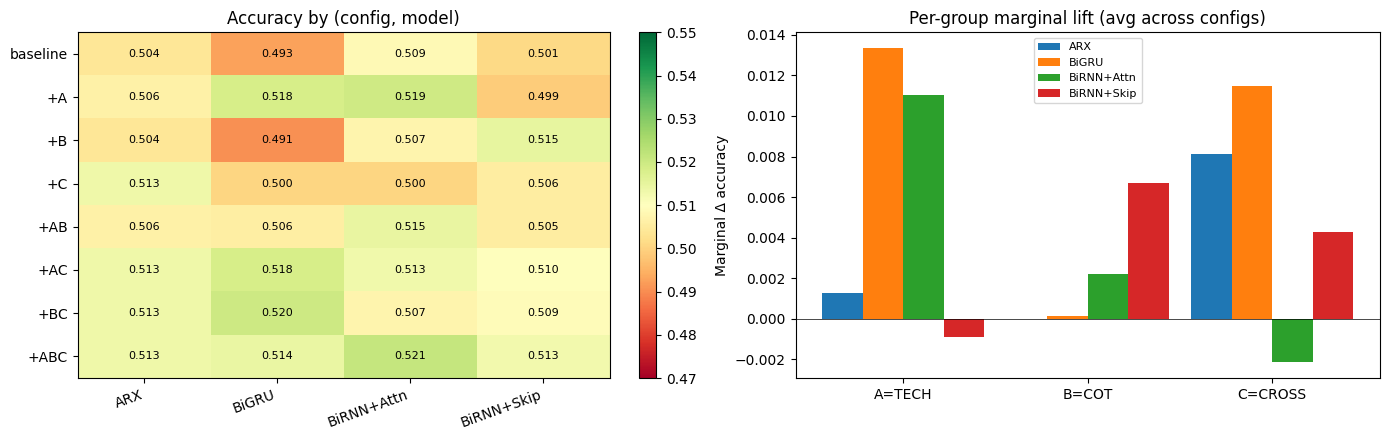


Best config per model:
  ARX       : +C        acc=0.5133  (Δ vs baseline = +0.0094)
  BiGRU     : +BC       acc=0.5197  (Δ vs baseline = +0.0271)
  BiRNN+Attn: +ABC      acc=0.5210  (Δ vs baseline = +0.0123)
  BiRNN+Skip: +B        acc=0.5149  (Δ vs baseline = +0.0138)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Heatmap of accuracy matrix
ax = axes[0]
im = ax.imshow(mat_acc.values, cmap='RdYlGn', vmin=0.47, vmax=0.55, aspect='auto')
ax.set_xticks(range(len(order_mdl))); ax.set_xticklabels(order_mdl, rotation=20, ha='right')
ax.set_yticks(range(len(order_cfg))); ax.set_yticklabels(order_cfg)
for i in range(mat_acc.shape[0]):
    for j in range(mat_acc.shape[1]):
        v = mat_acc.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                color='black', fontsize=8)
ax.set_title('Accuracy by (config, model)')
plt.colorbar(im, ax=ax, fraction=0.04)

# Marginal lift bar chart (per group, per model)
ax = axes[1]
x = np.arange(3)
w = 0.22
for i, m in enumerate(order_mdl):
    ax.bar(x + i*w - 1.5*w, ml_acc[m].values, w, label=m)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(['A=TECH', 'B=COT', 'C=CROSS'])
ax.set_ylabel('Marginal Δ accuracy')
ax.set_title('Per-group marginal lift (avg across configs)')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()

# Winner per model
print('\nBest config per model:')
for m in order_mdl:
    best_cfg = mat_acc[m].idxmax()
    best_acc = mat_acc.loc[best_cfg, m]
    delta = best_acc - mat_acc.loc['baseline', m]
    print(f'  {m:10s}: {best_cfg:8s}  acc={best_acc:.4f}  (Δ vs baseline = {delta:+.4f})')

## 12. Save artifacts

In [18]:
df.to_csv(OUT_DIR / 'phase2_ablation_summary.csv', index=False)
mat_acc.to_csv(OUT_DIR / 'phase2_ablation_acc_matrix.csv')
mat_auc.to_csv(OUT_DIR / 'phase2_ablation_auc_matrix.csv')
ml_acc.to_csv(OUT_DIR / 'phase2_marginal_lift_acc.csv')
ml_auc.to_csv(OUT_DIR / 'phase2_marginal_lift_auc.csv')

# Per-cell best params + per-fold details
all_params = {}
for r in results:
    k = f"{r['config']}_{r['model']}"
    all_params[k] = {
        'acc': r['acc'], 'auc': r['auc'], 'f1': r['f1'],
        'best_val_auc': r['best_val_auc'],
        'best_params': r['best_params'],
        'fold_accs': r['fold_accs'], 'fold_thr': r['fold_thr'],
        'n_features': r['n_features'], 'runtime_min': r['runtime_min'],
    }
with open(OUT_DIR / 'phase2_best_params.json', 'w') as f:
    json.dump(all_params, f, indent=2, default=str)

# Optuna trials per deep cell
for r in results:
    if 'trials_df' in r and r['trials_df'] is not None:
        fn = OUT_DIR / f"optuna_trials_{r['config'].replace('+','plus')}_{r['model'].replace('+','plus')}.csv"
        r['trials_df'].to_csv(fn, index=False)

print('Saved artifacts to:', OUT_DIR)
print(sorted(os.listdir(OUT_DIR)))

Saved artifacts to: /content/drive/MyDrive/Quants /phase2_ablation_artifacts
['optuna_trials_baseline_BiGRU.csv', 'optuna_trials_baseline_BiRNNplusAttn.csv', 'optuna_trials_baseline_BiRNNplusSkip.csv', 'optuna_trials_plusABC_BiGRU.csv', 'optuna_trials_plusABC_BiRNNplusAttn.csv', 'optuna_trials_plusABC_BiRNNplusSkip.csv', 'optuna_trials_plusAB_BiGRU.csv', 'optuna_trials_plusAB_BiRNNplusAttn.csv', 'optuna_trials_plusAB_BiRNNplusSkip.csv', 'optuna_trials_plusAC_BiGRU.csv', 'optuna_trials_plusAC_BiRNNplusAttn.csv', 'optuna_trials_plusAC_BiRNNplusSkip.csv', 'optuna_trials_plusA_BiGRU.csv', 'optuna_trials_plusA_BiRNNplusAttn.csv', 'optuna_trials_plusA_BiRNNplusSkip.csv', 'optuna_trials_plusBC_BiGRU.csv', 'optuna_trials_plusBC_BiRNNplusAttn.csv', 'optuna_trials_plusBC_BiRNNplusSkip.csv', 'optuna_trials_plusB_BiGRU.csv', 'optuna_trials_plusB_BiRNNplusAttn.csv', 'optuna_trials_plusB_BiRNNplusSkip.csv', 'optuna_trials_plusC_BiGRU.csv', 'optuna_trials_plusC_BiRNNplusAttn.csv', 'optuna_trials_plus